Loading data …
  7916 images | 7916 masks
  1247 images | 1247 masks
  2295 images | 2295 masks
Original train: 7916  Test (added to train): 2295
Combined train: 10211  Val: 1247
Batch — images: (8, 256, 256, 3) <dtype: 'float32'>  masks: (8, 256, 256, 1) <dtype: 'float32'>
Mask values — min: 0  max: 1  mean: 0.316
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Parameters: 24,207,764

=== PRE-TRAINING SANITY CHECK ===
Image 1 | min=0.012  max=0.398  mean=0.142  (target mean ≈ 0.24)
Image 2 | min=0.008  max=0.447  mean=0.147  (target mean ≈ 0.24)
Image 3 | min=0.015  max=0.386  mean=0.145  (target mean ≈ 0.24)
Image 4 | min=0.020  max=0.376  mean=0.157  (target mean ≈ 0.24)

PHASE 1 — Frozen encoder, training decoder only
Epochs: 30  |  LR: 0.0003
Training on 10211 images
Trainable: 6,531,957  |  Frozen: 17,675,807.0
Epoch 1/30
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - iou_metric: 0.4089 - loss: 0.7357
Epoch 1: val_iou_metric improved from -inf to 0.49674, saving model to best

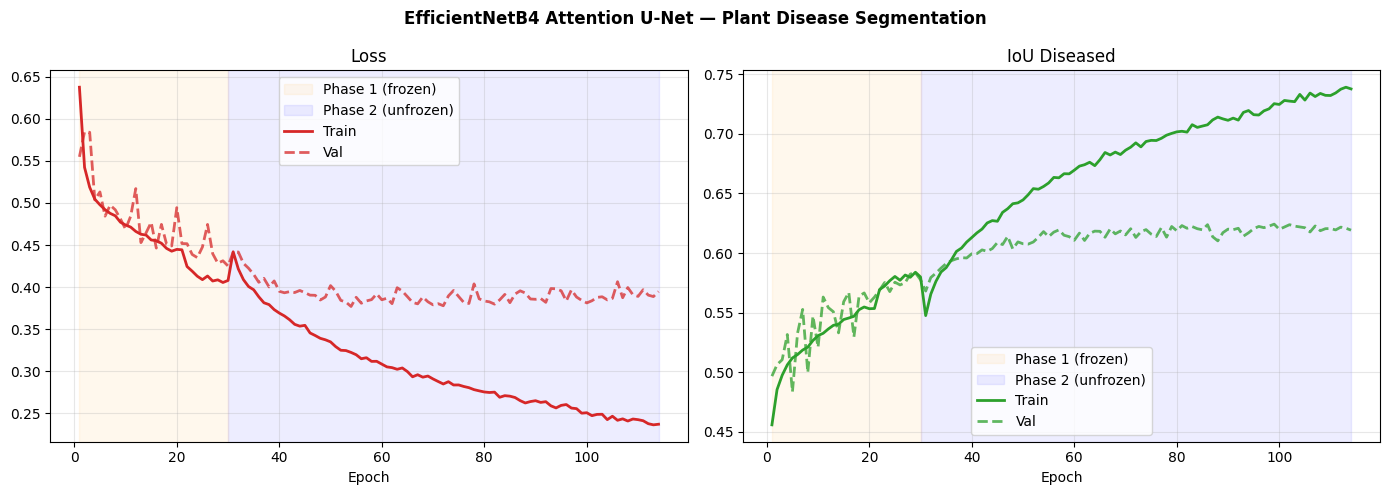

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import glob as glob_module
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras import layers, Model, callbacks
# tf.keras.mixed_precision.set_global_policy('mixed_float16')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Config ────────────────────────────────────────────────────────────────────
IMG_H           = 256
IMG_W           = 256
BATCH_SIZE      = 8
EPOCHS_FROZEN   = 30
EPOCHS_FINETUNE = 100
LR_FROZEN       = 3e-4
LR_FINETUNE     = 3e-5
CLASS_NAMES     = ['Background', 'Diseased']
INITIAL_BIAS    = float(np.log(0.238 / 0.762))

dataset_path      = '/kaggle/input/plant-disease-segmentation'
plantseg          = os.path.join(dataset_path, 'dataset')
images_train_path = os.path.join(plantseg, 'images',      'train')
masks_train_path  = os.path.join(plantseg, 'annotations', 'train')
images_val_path   = os.path.join(plantseg, 'images',      'val')
masks_val_path    = os.path.join(plantseg, 'annotations', 'val')
images_test_path  = os.path.join(plantseg, 'images',      'test')
masks_test_path   = os.path.join(plantseg, 'annotations', 'test')


# =============================================================================
# 1. DATA LOADING
# =============================================================================

def load_paths(img_dir, mask_dir):
    def _collect(folder):
        paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            paths.extend(glob_module.glob(os.path.join(folder, ext)))
        return sorted(paths)
    img_paths  = _collect(img_dir)
    mask_paths = _collect(mask_dir)
    assert len(img_paths)  > 0, f"No images in {img_dir}"
    assert len(mask_paths) > 0, f"No masks in {mask_dir}"
    assert len(img_paths) == len(mask_paths), "Image/mask count mismatch"
    print(f"  {len(img_paths)} images | {len(mask_paths)} masks")
    return img_paths, mask_paths

print("Loading data …")
train_imgs, train_masks = load_paths(images_train_path, masks_train_path)
val_imgs,   val_masks   = load_paths(images_val_path,   masks_val_path)
test_imgs,  test_masks  = load_paths(images_test_path,  masks_test_path)

# Combine train + test for training
all_train_imgs  = train_imgs + test_imgs
all_train_masks = train_masks + test_masks

print(f"Original train: {len(train_imgs)}  Test (added to train): {len(test_imgs)}")
print(f"Combined train: {len(all_train_imgs)}  Val: {len(val_imgs)}")


# =============================================================================
# 2. PREPROCESSING  (EfficientNet expects raw float32 0-255)
# =============================================================================

def preprocess_input(img_uint8):
    return img_uint8.astype(np.float32)


# =============================================================================
# 3. AUGMENTATION
# =============================================================================

def augment(img, mask):
    # ── Geometric transforms ──────────────────────────────────────────────────

    if np.random.rand() > 0.5:
        img  = cv2.flip(img,  1)
        mask = cv2.flip(mask, 1)

    if np.random.rand() > 0.5:
        img  = cv2.flip(img,  0)
        mask = cv2.flip(mask, 0)

    angle = np.random.uniform(-30, 30)
    M     = cv2.getRotationMatrix2D((IMG_W // 2, IMG_H // 2), angle, 1.0)
    img   = cv2.warpAffine(img,  M, (IMG_W, IMG_H),
                            flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REFLECT)
    mask  = cv2.warpAffine(mask, M, (IMG_W, IMG_H),
                            flags=cv2.INTER_NEAREST,
                            borderMode=cv2.BORDER_REFLECT)

    if np.random.rand() > 0.5:
        scale = np.random.uniform(0.7, 1.0)
        ch, cw = int(IMG_H * scale), int(IMG_W * scale)
        y0 = np.random.randint(0, IMG_H - ch)
        x0 = np.random.randint(0, IMG_W - cw)
        img  = cv2.resize(img[y0:y0+ch,  x0:x0+cw],
                          (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask[y0:y0+ch, x0:x0+cw],
                          (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)

    scale = np.random.uniform(0.9, 1.1)
    M     = cv2.getRotationMatrix2D((IMG_W // 2, IMG_H // 2), 0, scale)
    img   = cv2.warpAffine(img,  M, (IMG_W, IMG_H), flags=cv2.INTER_LINEAR)
    mask  = cv2.warpAffine(mask, M, (IMG_W, IMG_H), flags=cv2.INTER_NEAREST)

    # ── Colour transforms ─────────────────────────────────────────────────────

    img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    img_hsv[:, :, 0] = np.clip(
        img_hsv[:, :, 0] + np.random.uniform(-15, 15), 0, 180)
    img_hsv[:, :, 1] = np.clip(
        img_hsv[:, :, 1] * np.random.uniform(0.7, 1.3), 0, 255)
    img = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    alpha_bc = np.random.uniform(0.8, 1.2)
    beta_bc  = np.random.randint(-20, 20)
    img = np.clip(alpha_bc * img + beta_bc, 0, 255).astype(np.uint8)

    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 10, img.shape)
        img   = np.clip(img + noise, 0, 255).astype(np.uint8)

    if np.random.rand() > 0.6:
        n_holes = np.random.randint(1, 4)
        for _ in range(n_holes):
            hy = np.random.randint(20, 60)
            hx = np.random.randint(20, 60)
            y0 = np.random.randint(0, IMG_H - hy)
            x0 = np.random.randint(0, IMG_W - hx)
            img[y0:y0+hy, x0:x0+hx] = 0

    return img, mask


# =============================================================================
# 4. tf.data PIPELINE
# =============================================================================

def load_sample(img_path, mask_path, do_augment=False):
    if isinstance(img_path, bytes):
        img_path  = img_path.decode()
        mask_path = mask_path.decode()

    img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (IMG_W, IMG_H))
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)

    if do_augment:
        img, mask_u8 = augment(img, (mask * 255).astype(np.uint8))
        mask = (mask_u8 > 127).astype(np.float32)

    img = preprocess_input(img)
    return img.astype(np.float32), mask.astype(np.float32)


def make_dataset(img_paths, mask_paths, do_augment=False, shuffle=False):
    def _py(ip, mp):
        return load_sample(ip, mp, do_augment)

    def _tf(ip, mp):
        img, mask = tf.numpy_function(_py, [ip, mp],
                                       [tf.float32, tf.float32])
        img.set_shape([IMG_H, IMG_W, 3])
        mask.set_shape([IMG_H, IMG_W])
        return img, tf.expand_dims(mask, -1)

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(len(img_paths), seed=SEED)
    return (ds.map(_tf, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))


train_ds = make_dataset(all_train_imgs, all_train_masks,
                        do_augment=True,  shuffle=True)
val_ds   = make_dataset(val_imgs,        val_masks,
                        do_augment=False, shuffle=False)

for _x, _y in train_ds.take(1):
    print(f"Batch — images: {_x.shape} {_x.dtype}  "
          f"masks: {_y.shape} {_y.dtype}")
    print(f"Mask values — min: {_y.numpy().min():.0f}  "
          f"max: {_y.numpy().max():.0f}  "
          f"mean: {_y.numpy().mean():.3f}")


# =============================================================================
# 5. MODEL — EfficientNetB4 + Attention U-Net
# =============================================================================

def conv_block(x, filters, dropout_rate=0.0):
    reg = tf.keras.regularizers.l2(1e-4)
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv2D(filters, 1, padding='same')(g)

    # Get target shape from theta_x and resize phi_g to match
    h = theta_x.shape[1]
    w = theta_x.shape[2]
    phi_g = layers.Resizing(h, w, interpolation='bilinear')(phi_g)

    add  = layers.Add()([theta_x, phi_g])
    add  = layers.ReLU()(add)
    psi  = layers.Conv2D(1, 1, padding='same')(add)
    psi  = layers.Activation('sigmoid')(psi)
    return layers.Multiply()([x, psi])

def upsample_block(x, skip, filters, dropout_rate=0.0):
    """Standard upsample block — used for final stage (no skip)."""
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    if skip is not None:
        x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x


def upsample_block_attention(x, skip, filters, dropout_rate=0.0):
    """Upsample block with attention gate on skip connection."""
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    if skip is not None:
        skip = attention_gate(skip, x, filters // 2)
        x    = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x


def verify_layer_names(base):
    """Check all required skip connection layers exist."""
    skip_names = [
        'block2a_expand_activation',
        'block3a_expand_activation',
        'block4a_expand_activation',
        'block6a_expand_activation',
        'top_activation'
    ]
    print("\n=== LAYER NAME VERIFICATION ===")
    all_ok = True
    for name in skip_names:
        try:
            base.get_layer(name)
            print(f"  {name}")
        except:
            print(f"  ✗ {name} — NOT FOUND")
            all_ok = False
    if not all_ok:
        print("\nAvailable layers (last 30):")
        for l in base.layers[-30:]:
            print(f"  {l.name}")
    return all_ok


def build_model():
    base = tf.keras.applications.EfficientNetB4(
        input_shape=(IMG_H, IMG_W, 3),
        include_top=False,
        weights='imagenet')
    base.trainable = False

    inputs = base.input

    s1 = base.get_layer('block2a_expand_activation').output
    s2 = base.get_layer('block3a_expand_activation').output
    s3 = base.get_layer('block4a_expand_activation').output
    s4 = base.get_layer('block6a_expand_activation').output
    b  = base.get_layer('top_activation').output

    # Decoder with attention gates
    x = upsample_block_attention(b,  s4, 256, dropout_rate=0.4)
    x = upsample_block_attention(x,  s3, 128, dropout_rate=0.3)
    x = upsample_block_attention(x,  s2,  64, dropout_rate=0.2)
    x = upsample_block_attention(x,  s1,  32, dropout_rate=0.1)
    x = upsample_block(x, None, 16, dropout_rate=0.0)

    out = layers.Conv2D(
        1, 1, activation='sigmoid',
        bias_initializer=tf.keras.initializers.Constant(INITIAL_BIAS))(x)

    return Model(inputs=inputs, outputs=out,
                 name='EfficientNetB4-AttentionUNet'), base


model, base = build_model()
print(f"\nParameters: {model.count_params():,}")

print("\n=== PRE-TRAINING SANITY CHECK ===")
for i in range(4):
    img  = cv2.cvtColor(cv2.imread(val_imgs[i]), cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (IMG_W, IMG_H))
    pred = model.predict(
        np.expand_dims(preprocess_input(img), 0), verbose=0)[0, :, :, 0]
    print(f"Image {i+1} | min={pred.min():.3f}  max={pred.max():.3f}  "
          f"mean={pred.mean():.3f}  (target mean ≈ 0.24)")


# =============================================================================
# 6. LOSS + METRICS
# =============================================================================

def focal_dice_loss(y_true, y_pred, gamma=2.0, alpha=0.75, smooth=1e-6):
    bce     = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    p_t     = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
    focal   = tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    num = 2.0 * tf.reduce_sum(y_true * y_pred) + smooth
    den = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    return focal + (1.0 - num / den)


def iou_metric(y_true, y_pred):
    y_p   = tf.cast(y_pred > 0.35, tf.float32)
    inter = tf.reduce_sum(y_true * y_p)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_p) - inter
    return tf.math.divide_no_nan(inter, union + 1e-6)


# =============================================================================
# 7. CALLBACKS
# =============================================================================

cb_phase1 = [
    callbacks.ModelCheckpoint(
        'best_unet_phase1.keras', monitor='val_iou_metric',
        mode='max', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_iou_metric', factor=0.5, patience=5,
        mode='max', min_lr=1e-6, verbose=1),
    callbacks.CSVLogger('training_log_phase1.csv'),
]

cb_phase2 = [
    callbacks.ModelCheckpoint(
        'best_unet_phase2.keras', monitor='val_iou_metric',
        mode='max', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_iou_metric', factor=0.5, patience=12,
        mode='max', min_lr=1e-7, verbose=1),
    callbacks.EarlyStopping(
        monitor='val_iou_metric', patience=15,
        mode='max', restore_best_weights=True, verbose=1),
    callbacks.CSVLogger('training_log_phase2.csv'),
]


# =============================================================================
# 8. PHASE 1 — Frozen encoder, train decoder only
# =============================================================================

print("\n" + "="*60)
print("PHASE 1 — Frozen encoder, training decoder only")
print(f"Epochs: {EPOCHS_FROZEN}  |  LR: {LR_FROZEN}")
print(f"Training on {len(all_train_imgs)} images")
print("="*60)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(LR_FROZEN, weight_decay=1e-4),
    loss=focal_dice_loss,
    metrics=[iou_metric])

trainable   = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen      = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Trainable: {trainable:,}  |  Frozen: {frozen:,}")

history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=cb_phase1)

print(f"\nPhase 1 best val IoU: "
      f"{max(history1.history['val_iou_metric']):.4f}")


# =============================================================================
# 9. PHASE 2 — Fine-tune top 30% of encoder
# =============================================================================

print("\n" + "="*60)
print("PHASE 2 — Fine-tuning top 30% of encoder")
print("Loading best Phase 1 weights …")
model.load_weights('best_unet_phase1.keras')
print(f"Epochs: {EPOCHS_FINETUNE}  |  LR: {LR_FINETUNE}")
print("="*60)

base.trainable = True
freeze_until = int(len(base.layers) * 0.7)
for layer in base.layers[:freeze_until]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(LR_FINETUNE, weight_decay=1e-4),
    loss=focal_dice_loss,
    metrics=[iou_metric])

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Trainable after partial unfreeze: {trainable:,}")

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=cb_phase2)

print(f"\nPhase 2 best val IoU: "
      f"{max(history2.history['val_iou_metric']):.4f}")

model.save('unet_efficientnetb4.keras')
print("Saved → unet_efficientnetb4.keras")


# =============================================================================
# 10. TRAINING CURVES
# =============================================================================

def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB4 Attention U-Net — Plant Disease Segmentation',
             fontweight='bold')

for ax, (tr, vl, title, col) in zip(axes, [
        ('loss',       'val_loss',       'Loss',         'tab:red'),
        ('iou_metric', 'val_iou_metric', 'IoU Diseased', 'tab:green')]):
    t  = merge(history1, history2, tr)
    v  = merge(history1, history2, vl)
    ep = range(1, len(t) + 1)
    ax.axvspan(1, EPOCHS_FROZEN, alpha=0.07,
               color='orange', label='Phase 1 (frozen)')
    ax.axvspan(EPOCHS_FROZEN, len(t), alpha=0.07,
               color='blue', label='Phase 2 (unfrozen)')
    ax.plot(ep, t, label='Train', color=col, lw=2)
    ax.plot(ep, v, label='Val',   color=col, lw=2, ls='--', alpha=0.75)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


=== THRESHOLD TEST ===
  0.50 → IoU 0.5521
  0.47 → IoU 0.5537
  0.45 → IoU 0.5543
  0.42 → IoU 0.5549
  0.40 → IoU 0.5553
  0.37 → IoU 0.5552
  0.35 → IoU 0.5551
  0.32 → IoU 0.5539
  0.30 → IoU 0.5528
  0.27 → IoU 0.5506
  0.25 → IoU 0.5489

Best threshold: 0.4  IoU: 0.5553

Running full validation evaluation (with TTA) …

              precision    recall  f1-score   support

  Background     0.9377    0.8750    0.9052  65106251
    Diseased     0.6118    0.7721    0.6827  16617141

    accuracy                         0.8541  81723392
   macro avg     0.7748    0.8235    0.7940  81723392
weighted avg     0.8714    0.8541    0.8600  81723392



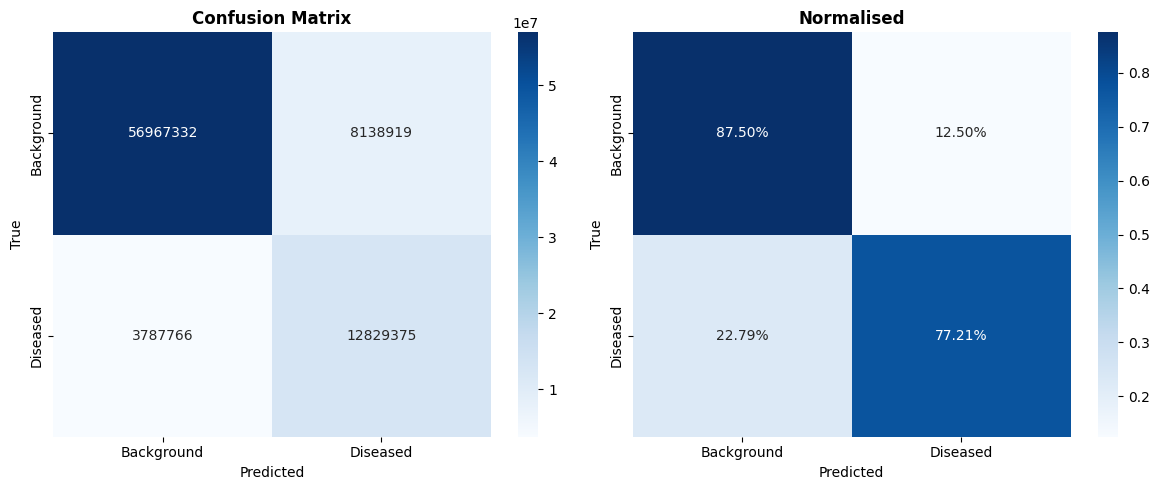

In [2]:
# =============================================================================
# 11. THRESHOLD TUNING
# =============================================================================

print("\n=== THRESHOLD TEST ===")
best_t, best_v = 0.5, 0.0
for thresh in [0.5, 0.47, 0.45, 0.42, 0.40, 0.37, 0.35, 0.32, 0.30, 0.27, 0.25]:
    ious = []
    for i in range(min(100, len(val_imgs))):
        img  = cv2.cvtColor(cv2.imread(val_imgs[i]), cv2.COLOR_BGR2RGB)
        img  = preprocess_input(cv2.resize(img, (IMG_W, IMG_H)))
        mask = cv2.imread(val_masks[i], cv2.IMREAD_GRAYSCALE)
        true = (cv2.resize(mask, (IMG_W, IMG_H),
                interpolation=cv2.INTER_NEAREST) > 0).astype(int)
        pred = model.predict(
            np.expand_dims(img, 0), verbose=0)[0, :, :, 0]
        p     = (pred > thresh).astype(int)
        inter = np.sum(true * p)
        union = np.sum(true) + np.sum(p) - inter
        ious.append(inter / (union + 1e-6))
    m = np.mean(ious)
    print(f"  {thresh:.2f} → IoU {m:.4f}")
    if m > best_v:
        best_v, best_t = m, thresh

print(f"\nBest threshold: {best_t}  IoU: {best_v:.4f}")
THRESHOLD = best_t


# =============================================================================
# 12. TTA PREDICTION
# =============================================================================

def predict_tta(model, img):
    """
    img shape: (1, H, W, 3) — single image with batch dim
    Returns: (1, H, W, 1)
    """
    # Remove batch dim for flipping, then re-add
    img_np = img[0]  # (H, W, 3)
    imgs = np.stack([
        img_np,
        img_np[:, ::-1, :],
        img_np[::-1, :, :],
        img_np[::-1, ::-1, :],
    ])  # (4, H, W, 3)

    preds = model.predict(imgs, verbose=0)  # (4, H, W, 1)

    # Flip predictions back before averaging
    preds[1] = preds[1, ::-1, :, :]       # undo horizontal flip
    preds[2] = preds[2, :, ::-1, :]       # undo vertical flip  
    preds[3] = preds[3, ::-1, ::-1, :]    # undo both

    mean_pred = preds.mean(axis=0)         # (H, W, 1)
    return np.expand_dims(mean_pred, 0)    # (1, H, W, 1)


# =============================================================================
# 13. VALIDATION EVALUATION (with TTA)
# =============================================================================

print("\nRunning full validation evaluation (with TTA) …")
all_true, all_pred = [], []
for ip, mp in zip(val_imgs, val_masks):
    img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    img  = preprocess_input(cv2.resize(img, (IMG_W, IMG_H)))
    mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    true = (cv2.resize(mask, (IMG_W, IMG_H),
            interpolation=cv2.INTER_NEAREST) > 0).astype(int)
    pred = predict_tta(model, np.expand_dims(img, 0))[0, :, :, 0]
    all_true.append(true.flatten())
    all_pred.append((pred > THRESHOLD).astype(int).flatten())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

print("\n" + "="*55)
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES, digits=4))

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d, fmt, t in zip(axes, [cm, cm_norm], ['d', '.2%'],
        ['Confusion Matrix', 'Normalised']):
    sns.heatmap(d, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(t, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



Loading best Phase 2 weights for final evaluation …

Running test set evaluation (with TTA) …

TEST SET RESULTS
              precision    recall  f1-score   support

  Background     0.9377    0.8750    0.9052  65106251
    Diseased     0.6118    0.7721    0.6827  16617141

    accuracy                         0.8541  81723392
   macro avg     0.7748    0.8235    0.7940  81723392
weighted avg     0.8714    0.8541    0.8600  81723392



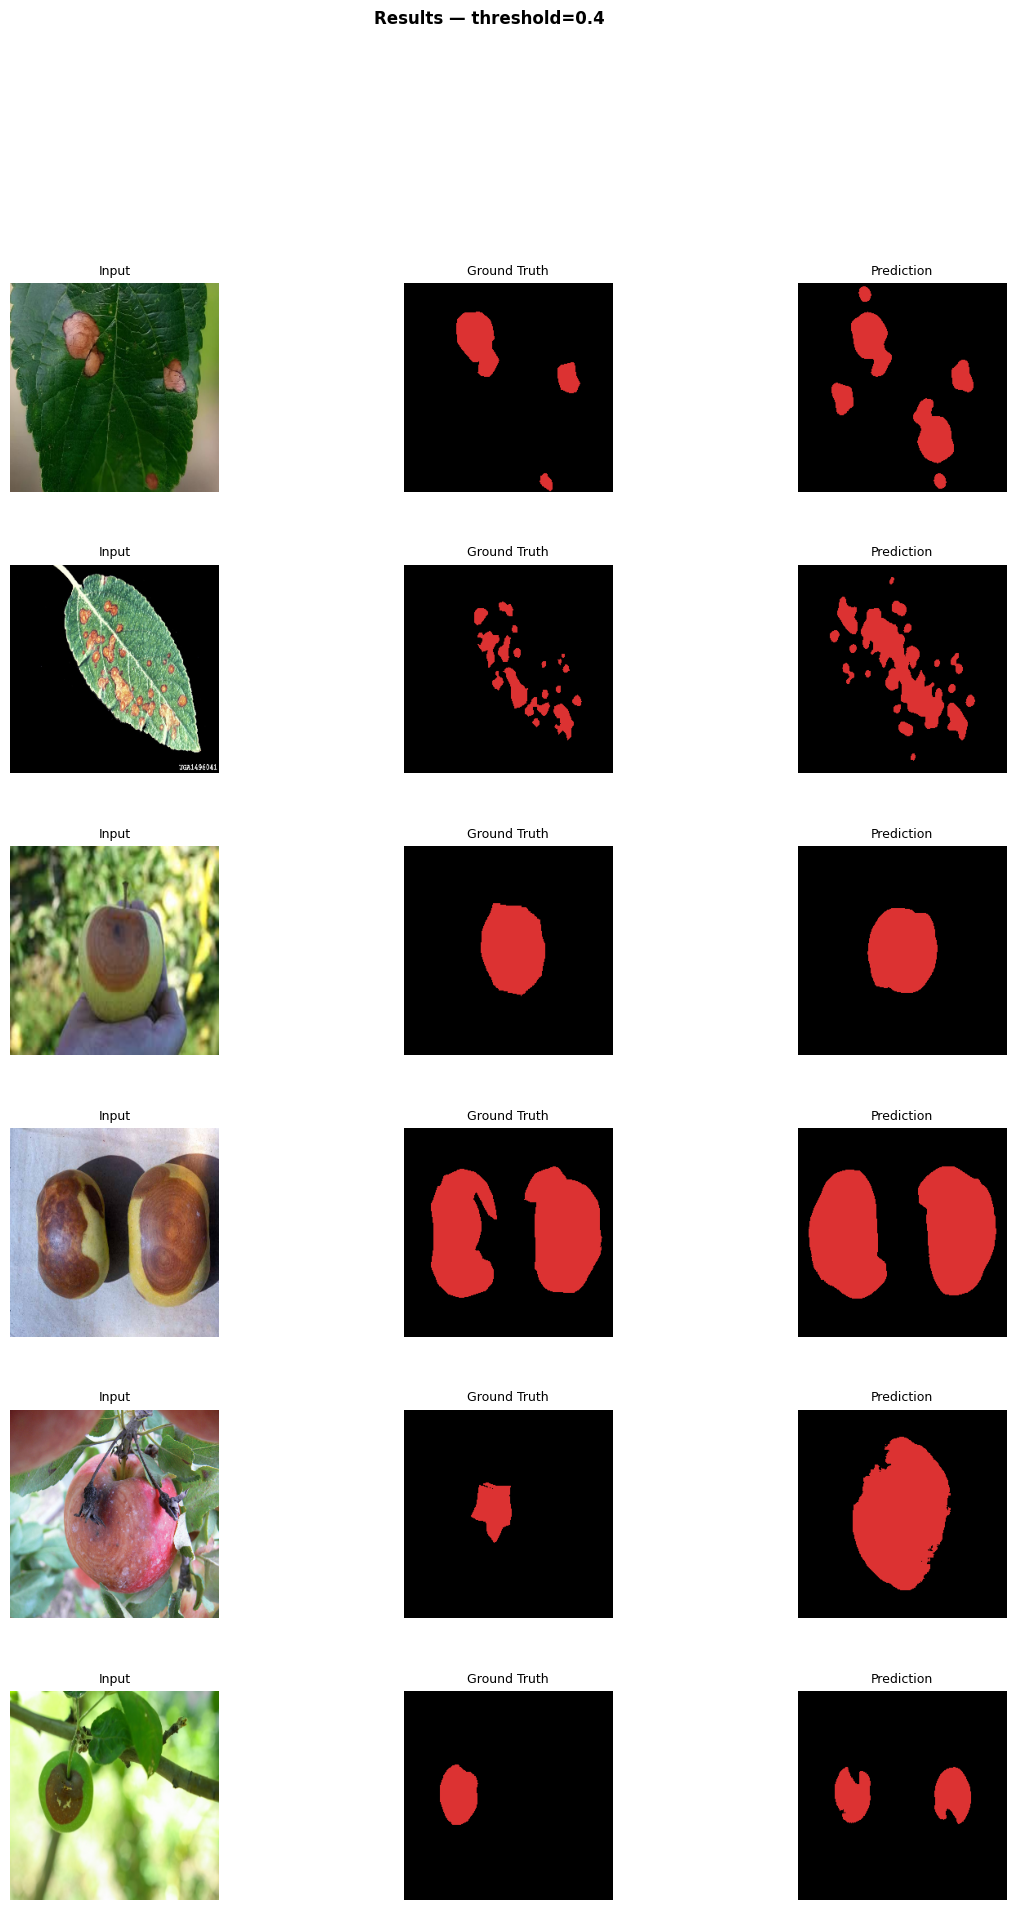

Files saved:
  unet_efficientnetb4.keras
  best_unet_phase1.keras
  best_unet_phase2.keras
  training_curves.png
  confusion_matrix.png
  qualitative_results.png
  training_log_phase1.csv
  training_log_phase2.csv


In [3]:
# =============================================================================
# 14. TEST SET EVALUATION (with TTA)
# =============================================================================

print("\nLoading best Phase 2 weights for final evaluation …")
model.load_weights('best_unet_phase2.keras')

print("\nRunning test set evaluation (with TTA) …")
all_true_test, all_pred_test = [], []
for ip, mp in zip(val_imgs, val_masks):
    img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    img  = preprocess_input(cv2.resize(img, (IMG_W, IMG_H)))
    mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    true = (cv2.resize(mask, (IMG_W, IMG_H),
            interpolation=cv2.INTER_NEAREST) > 0).astype(int)
    pred = predict_tta(model, np.expand_dims(img, 0))[0, :, :, 0]
    all_true_test.append(true.flatten())
    all_pred_test.append((pred > THRESHOLD).astype(int).flatten())

y_true_test = np.concatenate(all_true_test)
y_pred_test = np.concatenate(all_pred_test)

print("\n" + "="*55)
print("TEST SET RESULTS")
print(classification_report(y_true_test, y_pred_test,
                             target_names=CLASS_NAMES, digits=4))


# =============================================================================
# 15. QUALITATIVE RESULTS
# =============================================================================

PALETTE = {0: [0, 0, 0], 1: [220, 50, 50]}

def colorise(m):
    out = np.zeros((*m.shape, 3), dtype=np.uint8)
    for c, col in PALETTE.items():
        out[m == c] = col
    return out

n = min(6, len(val_imgs))
fig = plt.figure(figsize=(15, n * 3.5))
gs  = gridspec.GridSpec(n, 3, hspace=0.35, wspace=0.05)

for i in range(n):
    img_rgb = cv2.cvtColor(cv2.imread(val_imgs[i]), cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_W, IMG_H))
    img_pre = preprocess_input(img_rgb)

    mask     = cv2.imread(val_masks[i], cv2.IMREAD_GRAYSCALE)
    true_cls = (cv2.resize(mask, (IMG_W, IMG_H),
                interpolation=cv2.INTER_NEAREST) > 0).astype(int)
    pred     = predict_tta(model, np.expand_dims(img_pre, 0))[0, :, :, 0]
    pred_cls = (pred > THRESHOLD).astype(int)

    for j, (data, title) in enumerate([
            (img_rgb.astype(np.float32) / 255., 'Input'),
            (colorise(true_cls),                'Ground Truth'),
            (colorise(pred_cls),                'Prediction')]):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(data); ax.set_title(title, fontsize=9); ax.axis('off')

fig.suptitle(f'Results — threshold={THRESHOLD}',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Files saved:")
print("  unet_efficientnetb4.keras")
print("  best_unet_phase1.keras")
print("  best_unet_phase2.keras")
print("  training_curves.png")
print("  confusion_matrix.png")
print("  qualitative_results.png")
print("  training_log_phase1.csv")
print("  training_log_phase2.csv")